<a href="https://colab.research.google.com/github/LucioFassarella/Ensino/blob/main/EDO_MetodoEuler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método de Euler

O <i>Método de Euler</i> é um método simples e recursivo para resolver numericamente equações diferenciais ordinárias de primeira ordem com condições iniciais dadas.

🖖



Considere uma EDO com condição inicial
$$\tag{EDO}
\left\lbrace
\begin{array}{l}
\dfrac{d y}{dx} = F(x,y),\\
y(x_0) = y_0.
\end{array}
\right.
$$
O Método de Euler é baseado na aproximação linear local de funções diferenciáveis:
$$
y(x + \Delta x) \approx y(x) + y'(x)\Delta x\ \ (\Delta x \approx 0).
$$

**Algoritmo**

Dado um ponto $x_* > x_0$ no domínio da função $F$, o Método de Euler para determinar uma aproximação para a solução da EDO no intervalo $\left\lbrack x_0,x_* \right\rbrack$ consiste em:

1. Definir uma variação suficientemente pequena para a variável $x$, digamos $\Delta x >0$;
2. Calcular $N = \lceil \frac{x_* - x_0}{\Delta x} \rceil $, o número de recorrências;
3. Calcular recursivamente:
$$
\left\lbrace
\begin{array}{l}
y_{k} = y_{k-1} + F(x_{k-1},y_{k-1})\Delta x;\ k = 1, \dots, N.
\end{array}
\right.
$$

🖖

## Exemplo 1: Resolução numérica da equação da velocidade de um corpo em queda livre

Aqui, o Método de Euler é aplicado à resolução da <i>equação diferencial para a velocidade de um objeto em queda livre sob resistência do ar</i>:

$$
\dfrac{d v}{dt} = - mg - k_1 v - k_2 v\vert v \vert,
$$

onde $m> 0$, $g>0$, $k_1>0$ e $k_2>0$ são constantes, <i>viz.</i>, a massa do objeto, a aceleração da gravidade e as constantes de resistência do ar (de primeira e segunda ordens).

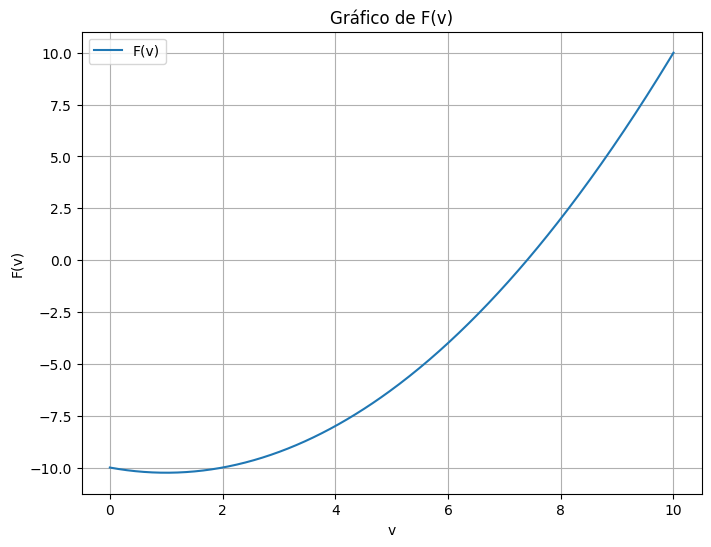

In [ ]:
'''
Função característica da EDO:
'''

import numpy as np

m = 1 # (kilo)
g = 10 #(metros por segundo por segundo)
k1 = 0.5 #(kilo por segundo)
k2 = 0.25 # (kilo por metro)
def F(v):
    return - m*g - k1*v + k2*v**2


# Plotagem de F(v)

import matplotlib.pyplot as plt

v = np.linspace(0,10, 400)  # Abscissas dos pontos do gráfico
R = F(v)  # Ordenadas dos pontos do gráfico

plt.figure(figsize=(8, 6))
plt.plot(v, R, label='F(v)')
plt.title('Gráfico de F(v)')
plt.xlabel('v')
plt.ylabel('F(v)')
plt.grid(True)
plt.legend()
plt.show()

Parâmetros do problema
m = 1 kg
g = 10 m/s**2
k1 = 0.5 kg/s
k2 = 0.25 kg/m
t_0 = 0 s
v_0 = 0 m/s
t_final = 10 s
dt = 0.1 s
N = 100


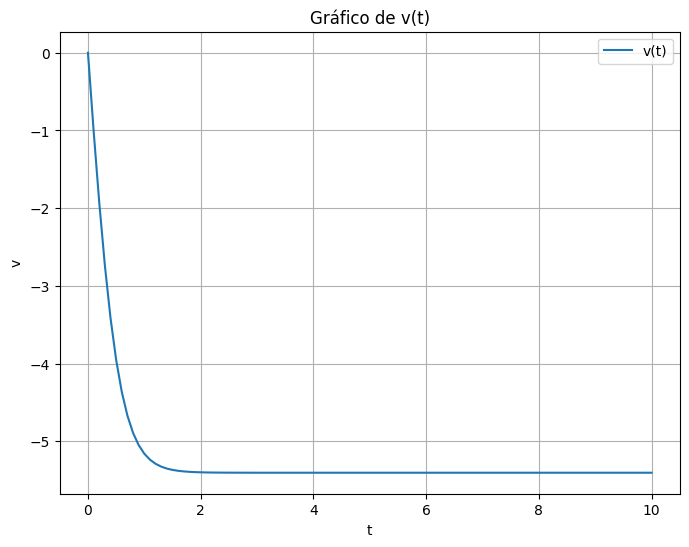

Velocidade final aproximada: -5.403124237432848 m/s**2


In [ ]:
'''
Resolução numérica da EDO pelo Método de Euler
'''

# Ponto inicial
t_0 = 0 #(segundo)
v_0 =  0 #(metros / segundo)

# Ponto final
t_final = 10 # (segundos)

# Variação do tempo (passo)
dt = 10**(-1)

# Número de recorrências:
N = int(np.ceil((t_final - t_0)/dt))

# Recorrência
t = [t_0 + k_val*dt for k_val in range(N+1)] # Renamed loop variable from k to k_val to avoid conflict with global k

v = [v_0 for k_val in range(N+1)]

for k_val in range(1,N+1):
    v[k_val] = v[k_val-1] + F(v[k_val-1])*dt

# Print dos parâmetros
print("Parâmetros do problema")
print(f"m = {m} kg")
print(f"g = {g} m/s**2")
print(f"k1 = {k1} kg/s")
print(f"k2 = {k2} kg/m")

print(f"t_0 = {t_0} s")
print(f"v_0 = {v_0} m/s")
print(f"t_final = {t_final} s")
print(f"dt = {dt} s")
print(f"N = {N}")

# Plotagem da solução numérica

plt.figure(figsize=(8, 6))
plt.plot(t, v, label='v(t)')
plt.title('Gráfico de v(t)')
plt.xlabel('t')
plt.ylabel('v')
plt.grid(True)
plt.legend()
plt.show()

print(f"Velocidade final aproximada: {v[N]} m/s**2")

## Exemplo 2: Resolução numérica da equação de movimento de um pêndulo simples

Equação do pêndulo simples, com variável dependente sendo o ângulo do pêndulo em relação à direção vertical:

$$
\dfrac{d^2\theta}{dt^2} + \frac{g}{L}\sin(\theta) = 0,
$$
onde $g>0$ é a aceleração da gravidade local e $L>0$ é o comprimento do pêndulo.

<font color="grey">(Observe que o movimento não depende da massa do pêndulo. Isso acontece porque a inércia e a aceleração do pêndulo são proporcionais à massa; consequentemente, o efeito combinado desses fatores acaba candelando a influência da massa no movimento.)</font>

Para aplicar o Método de Euler a este caso, precisamos reduzir a EDO original (de segunda ordem) para uma EDO de primeira ordem, o que é feito pela introdução de uma nova variável dependente, digamos

$$
v = d\theta/dt.
$$

A EDO do pêndulo com redução de ordem e condições iniciais é dada por:

$$
\left\lbrace
\begin{array}{l}
\dfrac{d\theta}{dt} = v,\\
\dfrac{d v}{dt} = - \dfrac{g}{L}\sin(\theta);\\
\theta(t_0) = \theta_0,\ \ \ \ \text{(posição inicial do pêndulo)}\\
v(t_0) = v_0. \ \ \ \ \text{(velocidade inicial do pêndulo)}
\end{array}
\right.
$$

Parâmetros do problema
g = 9.8 m/s**2
L = 1 m
t_0 = 0 s
theta_0 = 0.7853981633974483 kg
v_0 = 0 m/s
t_final = 10 s
dt = 0.01 s
N = 1000


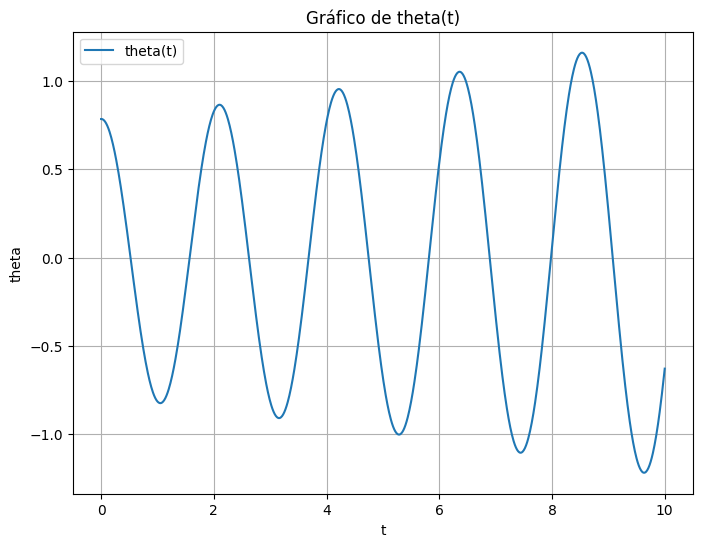

In [ ]:
'''
Resolução numérica da EDO pelo Método de Euler
'''

import numpy as np

# Parâmetros do problema

g = 9.8 #(m/s**2)
L = 1 #(m)

# Condições iniciais
t_0 = 0 #(segundo)
theta_0 = np.pi/4
v_0 =  0 #(metros / segundo)

# Instante final
t_final = 10 # (segundos)

# Variação do tempo (passo)
dt = 10**(-2)

# Número de recorrências:
N = int(np.ceil((t_final - t_0)/dt))

# Recorrência
t = [t_0 + k_val*dt for k_val in range(N+1)] # Renamed loop variable from k to k_val to avoid conflict with global k

v = [v_0 for k_val in range(N+1)]
theta = [theta_0 for k_val in range(N+1)]

for k in range(1,N+1):
    theta[k] = theta[k -1] + v[k -1]*dt
    v[k] = v[k -1] - (g/L)*np.sin (theta[k -1])*dt

# Print dos parâmetros
print("Parâmetros do problema")
print(f"g = {g} m/s**2")
print(f"L = {L} m")

print(f"t_0 = {t_0} s")
print(f"theta_0 = {theta_0} kg")
print(f"v_0 = {v_0} m/s")
print(f"t_final = {t_final} s")
print(f"dt = {dt} s")
print(f"N = {N}")

# Plotagem da solução numérica

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(t, theta, label='theta(t)')
plt.title('Gráfico de theta(t)')
plt.xlabel('t')
plt.ylabel('theta')
plt.grid(True)
plt.legend()
plt.show()